# Bivariate Analysis
### Analyzing Relationships, Group Differences, and Contingencies Between Pairs of Features

---

### Scope & Focus of This Notebook
- **Primary Topic**: Bivariate Exploratory Data Analysis — analyzing pairwise relationships between two variables at a time.
- **What You Will Learn**:
  1. **Numerical + Numerical**: Scatter plots (`sns.scatterplot`), trend lines (`sns.lineplot`), and matrix pair plots (`sns.pairplot`).
  2. **Numerical + Categorical**: Bar plots of group means (`sns.barplot`), grouped box plots (`sns.boxplot`), and multi-group KDE density curves (`sns.kdeplot(hue=...)`).
  3. **Categorical + Categorical**: Two-way contingency tables (`pd.crosstab`), raw counts vs. row percentages, contingency heatmaps, and hierarchical cluster maps (`sns.clustermap`).
- **What We Will NOT Cover Here**:
  - Single-variable distributions (histograms, single box plots, value counts) were covered in **`01_Univariate_Analysis`**.
  - Multi-variable interactions (3 or more variables simultaneously) belong to **`03_Multivariate_Analysis`**.
  - Automated profiling reports are in **`04_Pandas_Profiling`**.
  - Preprocessing, scaling, and categorical encoding belong to **`Module 03: Feature Engineering`**.

---

## 1. Setup & Load Dataset

### What are we doing?
We import data science libraries (`pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`) and load the Titanic dataset using robust relative path checking.

#### What do these libraries do here?
- `pandas`: Two-way contingency tables (`pd.crosstab`) and group aggregations.
- `seaborn` & `matplotlib.pyplot`: Pairwise relationship plotting, grouped distributions, and correlation/contingency maps.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Robust path resolution
data_path = '../../data/titanic.csv' if os.path.exists('../../data/titanic.csv') else 'data/titanic.csv'
df = pd.read_csv(data_path)

print(f"Loaded Titanic dataset: {df.shape[0]} rows, {df.shape[1]} columns")


Loaded Titanic dataset: 891 rows, 12 columns


## 2. Numerical + Numerical Analysis

Analyzing two continuous variables simultaneously to examine correlation, non-linear relationships, clusters, and extreme joint outliers.

---

### 2.1 Scatter Plot (`sns.scatterplot`)

### What are we doing?
We plot passenger `Age` on the horizontal axis and `Fare` on the vertical axis.

#### What does `sns.scatterplot()` do?
Plots Cartesian coordinates $(x_i, y_i)$ for each observation as an individual point in 2D space.

#### Why are we using it?
To visually discover the nature of the relationship (linear, exponential, clustered, or random noise).

#### Important Parameters:
- `data`: The DataFrame.
- `x`, `y`: Continuous feature names.
- `alpha`: Point transparency to reveal overlapping data points.

#### What is the implication?
Most passengers paid under £100 regardless of age, but a distinct cluster of luxury passengers paid over £200, including isolated £512 fares across varied adult ages.


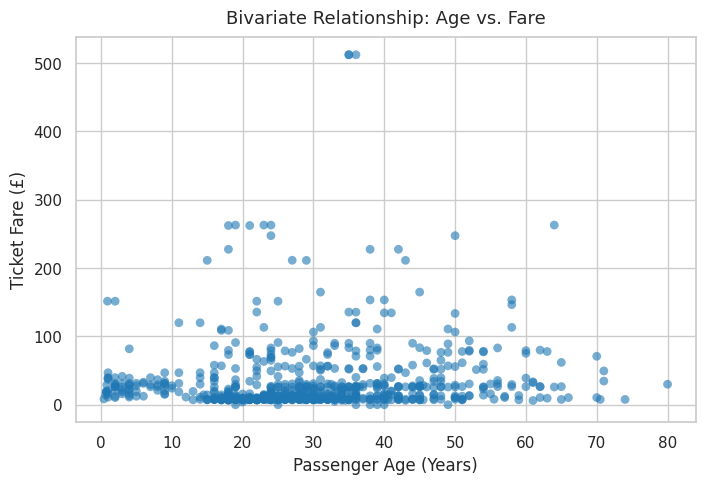

In [2]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, 
    x='Age', 
    y='Fare', 
    alpha=0.6, 
    color='#1f77b4', 
    edgecolor='none', 
    s=40
)
plt.title('Bivariate Relationship: Age vs. Fare', fontsize=13, pad=10)
plt.xlabel('Passenger Age (Years)')
plt.ylabel('Ticket Fare (£)')

# Save plot robustly
plot_dir = '../../outputs/plots' if os.path.exists('../../outputs/plots') else ('outputs/plots' if os.path.exists('outputs/plots') else '.')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'bivariate_scatter_age_fare.png'), dpi=150)
plt.show()


### 2.2 Line Plot (`sns.lineplot`)

### What are we doing?
We examine how the average ticket fare changes as age increases, binning ages into rounded intervals to track the mean trend with shaded confidence bands.

#### What does `sns.lineplot()` do?
Aggregates multiple $y$ values sharing the same $x$ coordinate, computing and drawing the mean line and a 95% bootstrap confidence interval band.

#### What is the implication?
Average ticket fare stays relatively flat between 15 and 30, but rises significantly for passengers in their 30s to 50s before dropping again in older retirement years.


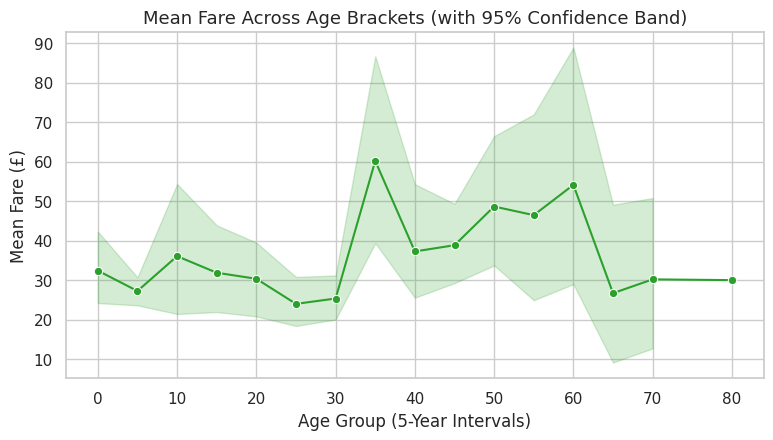

In [3]:
# Create Age brackets rounded to nearest 5 years for clean line aggregation
df_temp = df.copy()
df_temp['Age_Round'] = (df_temp['Age'] // 5) * 5

plt.figure(figsize=(9, 4.5))
sns.lineplot(data=df_temp, x='Age_Round', y='Fare', color='#2ca02c', errorbar=('ci', 95), marker='o')
plt.title('Mean Fare Across Age Brackets (with 95% Confidence Band)', fontsize=13)
plt.xlabel('Age Group (5-Year Intervals)')
plt.ylabel('Mean Fare (£)')
plt.show()


### 2.3 Pair Plot (`sns.pairplot`)

### What are we doing?
We generate a pairwise matrix of scatter plots for all numerical features in our dataset.

#### What does `sns.pairplot()` do?
Renders an $N \times N$ grid where diagonal cells display univariate histograms/KDEs and off-diagonal cells display bivariate scatter plots between every pair of features.

#### Why are we using it?
To rapidly survey all numerical pairwise relationships in a single operation.

#### What is the implication?
Enables rapid visual screening of collinear features, clusters, and unusual joint distributions across the entire dataset.


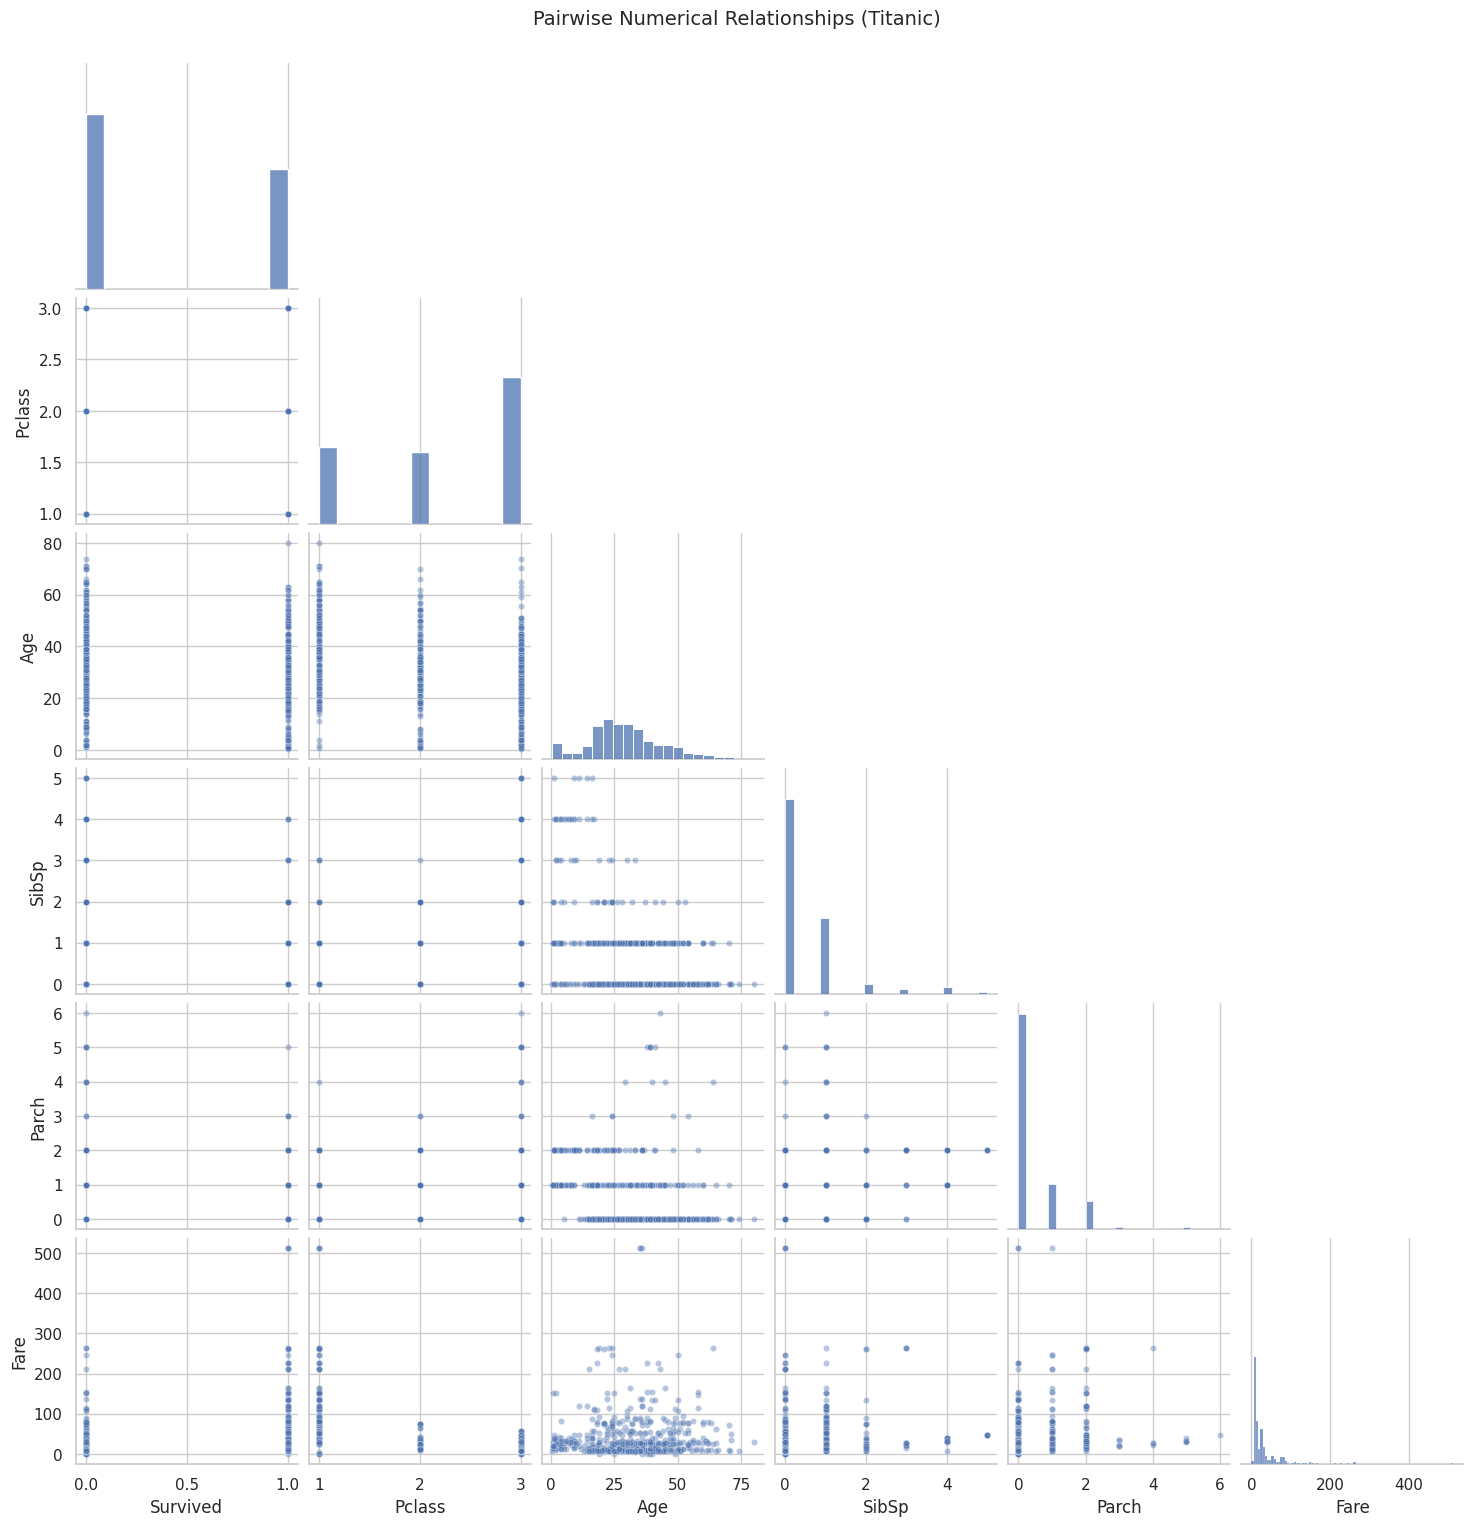

In [4]:
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

g = sns.pairplot(df[num_cols].dropna(), corner=True, plot_kws={'alpha': 0.4, 's': 20})
g.fig.suptitle('Pairwise Numerical Relationships (Titanic)', y=1.02, fontsize=14)

# Save plot
plt.savefig(os.path.join(plot_dir, 'bivariate_pairplot.png'), dpi=150)
plt.show()


## 3. Numerical + Categorical Analysis

Evaluating how continuous numerical metrics vary across distinct categorical groups.

---

### 3.1 Grouped Bar Plot (`sns.barplot`)

### What are we doing?
We compare the mean ticket fare across passenger classes (`Pclass`).

#### What does `sns.barplot()` do?
Computes the mean of the numerical variable for each categorical level and displays error bars indicating the 95% confidence interval of the mean estimate.

#### What is the implication?
Class 1 paid an average fare of ~£84, compared to ~£20.7 in Class 2 and ~£13.7 in Class 3, showing a massive financial gulf between classes.


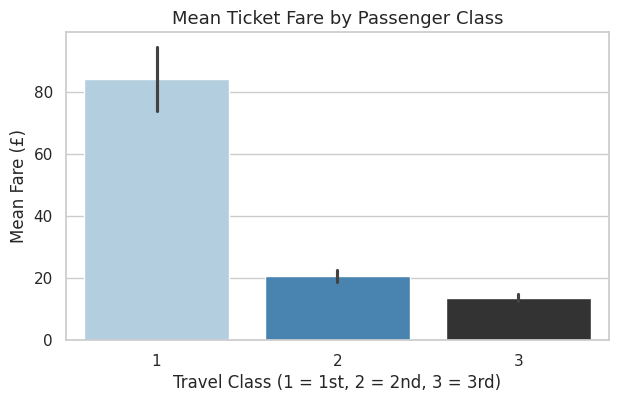

In [5]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='Pclass', y='Fare', palette='Blues_d', hue='Pclass', legend=False)
plt.title('Mean Ticket Fare by Passenger Class', fontsize=13)
plt.xlabel('Travel Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Mean Fare (£)')
plt.show()


### 3.2 Box Plot by Category (`sns.boxplot(x=..., y=...)`)

### What are we doing?
We compare the full age distribution across the 3 passenger classes using side-by-side box plots.

#### Why use a Box Plot instead of a Bar Plot?
A bar plot only shows the single mean value and hides the entire distribution. The box plot shows median, dispersion (IQR), and outliers for every group simultaneously.

#### What is the implication?
1st class passengers were substantially older (median ~37 years) than 2nd class (median ~29 years) and 3rd class (median ~24 years).


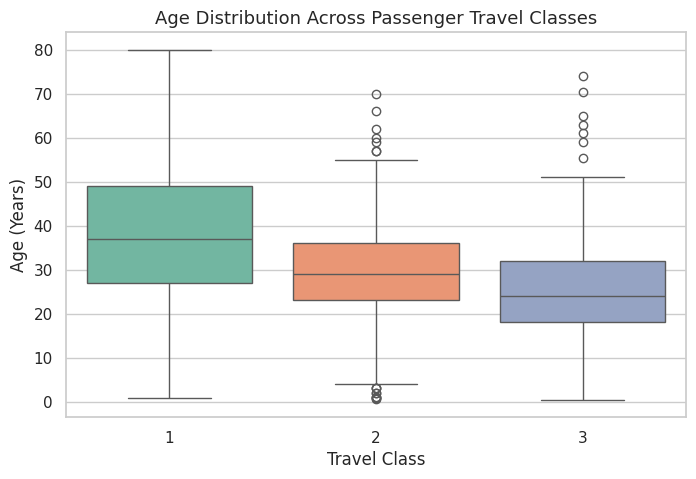

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Pclass', y='Age', palette='Set2', hue='Pclass', legend=False)
plt.title('Age Distribution Across Passenger Travel Classes', fontsize=13)
plt.xlabel('Travel Class')
plt.ylabel('Age (Years)')
plt.show()


### 3.3 Grouped Density Curve (`sns.kdeplot(hue=...)`)

### What are we doing?
We overlay continuous age density distributions separated by survival status (`Survived`).

#### What does `hue` do here?
Splits the continuous density calculation into independent colored curves for each level of the categorical feature.

#### What is the implication?
The red curve (survived) has a distinct bump in the young infant age bracket (0 to 5 years), reflecting the "women and children first" maritime evacuation protocol.


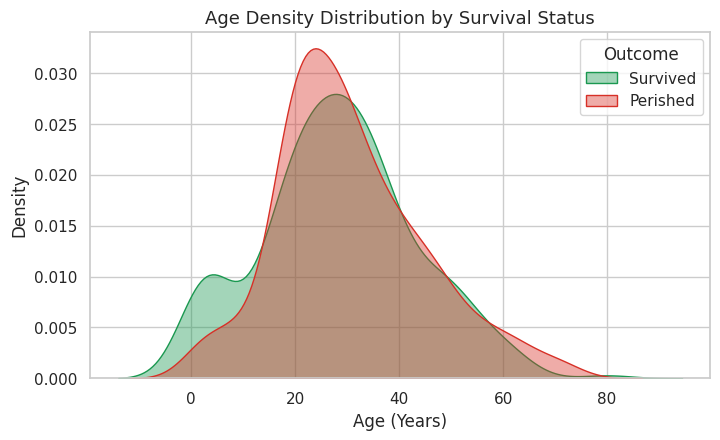

In [7]:
plt.figure(figsize=(8, 4.5))
sns.kdeplot(data=df, x='Age', hue='Survived', common_norm=False, fill=True, palette={0: '#d73027', 1: '#1a9850'}, alpha=0.4)
plt.title('Age Density Distribution by Survival Status', fontsize=13)
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.legend(title='Outcome', labels=['Survived', 'Perished'])
plt.show()


## 4. Categorical + Categorical Analysis

Examining dependencies and conditional probabilities between two qualitative variables.

---

### 4.1 Two-Way Contingency Table (`pd.crosstab`)

### What are we doing?
We compute a contingency table crossing passenger `Sex` against `Survived`.

#### What does `pd.crosstab()` do?
Computes a simple frequency cross-tabulation of two or more factors.

#### Why are row percentages essential?
Raw counts can be deceptive because total counts of men and women differ substantially. Using `normalize='index'` computes the conditional probability:
$$P(\text{Survived} \mid \text{Gender})$$

#### What is the implication?
- Female survival rate: **74.2%** (233 out of 314 survived).
- Male survival rate: **18.9%** (109 out of 577 survived).
Gender is the single most decisive predictive factor in the Titanic dataset.


In [8]:
# Raw contingency counts
raw_counts = pd.crosstab(df['Sex'], df['Survived'], margins=True)
print("--- Raw Passenger Counts ---")
display(raw_counts)

# Conditional row percentages
pct_table = (pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100).round(2)
print("\n--- Conditional Survival Rates (Row Percentages %) ---")
display(pct_table)


--- Raw Passenger Counts ---


Survived,0,1,All
Sex,,,
female,81,233,314
male,468,109,577
All,549,342,891



--- Conditional Survival Rates (Row Percentages %) ---


Survived,0,1
Sex,,
female,25.80,74.20
male,81.11,18.89


### 4.2 Contingency Heatmap (`sns.heatmap`)

### What are we doing?
We visualize the conditional percentage table as an annotated heatmap.

#### What does `sns.heatmap()` do?
Draws an annotated rectangular grid where cell colors indicate conditional rates.


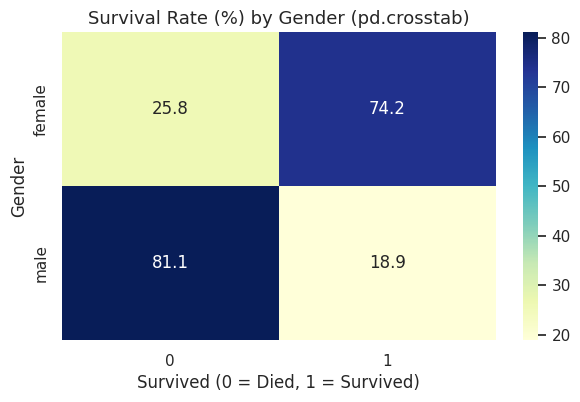

In [9]:
plt.figure(figsize=(7, 4))
sns.heatmap(
    pct_table, 
    annot=True, 
    fmt='.1f', 
    cmap='YlGnBu', 
    cbar=True
)
plt.title('Survival Rate (%) by Gender (pd.crosstab)', fontsize=13)
plt.xlabel('Survived (0 = Died, 1 = Survived)')
plt.ylabel('Gender')

# Save plot
plt.savefig(os.path.join(plot_dir, 'bivariate_crosstab_gender_survival.png'), dpi=150)
plt.show()


### 4.3 Hierarchical Cluster Map (`sns.clustermap`)

### What are we doing?
We compute survival rates across all combinations of `Pclass` and `Embarked` and apply hierarchical clustering.

#### What does `sns.clustermap()` do?
Plots a matrix heatmap with hierarchical dendrogram trees along rows and columns, clustering similar profiles together.

#### What is the implication?
Reveals which boarding ports and passenger classes experienced similar survival outcomes.


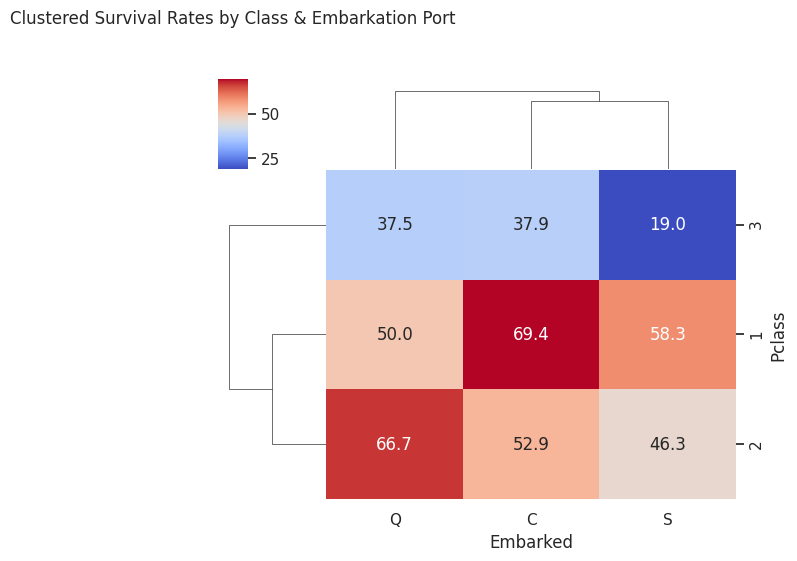

In [10]:
cluster_data = pd.crosstab(
    df['Pclass'], 
    df['Embarked'], 
    values=df['Survived'], 
    aggfunc='mean'
).fillna(0) * 100

sns.clustermap(cluster_data, annot=True, fmt='.1f', cmap='coolwarm', figsize=(6, 5))
plt.title('Clustered Survival Rates by Class & Embarkation Port', pad=40)
plt.show()


---

## What We Learned
- **Numerical + Numerical Relationships**: Scatter plots expose non-linear curves, line plots show smoothed average trends, and pair plots provide whole-dataset visual screening.
- **Numerical + Categorical Comparisons**: Box plots are superior to bar plots because they display the full distribution, medians, and outliers across groups rather than just a single mean.
- **Grouped Density Estimation**: Overlaying KDE curves with `hue` isolates subtle sub-population shifts (such as high infant survival).
- **Categorical Contingency Analysis**: `pd.crosstab(normalize='index')` reveals conditional probabilities that raw frequency counts hide.
- **Hierarchical Clustering**: `sns.clustermap` automatically groups similar category combinations using dendrograms.

---

## Important Takeaways
1. **Never rely on raw counts in two-way tables**: Always compute conditional row percentages (`normalize='index'`) to prevent sample size distortion.
2. **Never rely on bar charts alone for group comparisons**: Always use grouped box plots or violin plots to check whether extreme values are distorting the group mean.
3. **Scatter plots require transparency tuning**: On dense datasets, use `alpha` or small marker sizes to detect hidden clusters.

---

## Common Mistakes
1. **Confusing conditional probabilities**: In `pd.crosstab`, `normalize='index'` (row %) answers "What % of women survived?", whereas `normalize='columns'` (col %) answers "What % of survivors were women?".
2. **Assuming linear relationship from scatter plots**: A curved or parabolic cloud of points has high predictive value but near-zero linear correlation.
3. **Ignoring group sample sizes**: A group with 3 passengers having a 100% survival rate is not statistically comparable to a group with 500 passengers having a 40% survival rate.

---

## Final Mental Model

```text
┌────────────────────────────────────────────────────────────────────────┐
│                      BIVARIATE ANALYSIS MATRIX                         │
└────────────────────────────────────────────────────────────────────────┘
          │
          ├──► Num + Num  ──► sns.scatterplot()  : Pairwise points
          │               ──► sns.lineplot()     : Trend & confidence band
          │               ──► sns.pairplot()     : All-pairs matrix
          │
          ├──► Num + Cat  ──► sns.boxplot()      : Grouped five-number distributions
          │               ──► sns.kdeplot(hue)   : Overlaid density curves
          │               ──► sns.barplot()      : Group means
          │
          └──► Cat + Cat  ──► pd.crosstab()      : Contingency table (row %)
                          ──► sns.heatmap()      : Contingency visualization
                          ──► sns.clustermap()   : Hierarchical group clustering
```
